# FCC Iso-Embedding Distance Metrics vs Misorientation

Purpose: measure how two embedding distances in the FCC local-iso representation change as orientations drift apart:
- Euclidean distance: `l2 = ||f(q) - f(q_ref)||_2`
- absolute L1 distance: `l1 = ||f(q) - f(q_ref)||_1`

This lets us choose a principled neighbor filter for OCRP or HR conv refinement, while keeping the isometric interpretation explicit.

Question being answered:
- If we gate neighbors by embedding distance, what `l2` or `l1` cutoff roughly corresponds to a given FCC misorientation angle?

Main practical takeaway from the probe used to build this notebook:
- `l2 <= 0.035` is about `<= 2 deg`
- `l2 <= 0.070` is about `<= 4 deg`
- `l2 <= 0.090` is about `<= 5 deg`
- `l2 <= 0.120` is about `<= 6 deg`
- `l2 <= 0.150` is about `<= 8 deg`
- `l2 <= 0.200` is about `<= 11 deg`
- `l1 <= 0.12` is about `<= 3 deg`
- `l1 <= 0.18` is about `<= 5 deg`
- `l1 <= 0.25` is about `<= 6 deg`
- `l1 <= 0.30` is about `<= 8 deg`

Over this fixed-reference sweep, `l2` is nearly identical to the misorientation angle expressed in radians, which is what we want from an isometric embedding. The L1 curve is included for comparison, but `l2` is the more natural geometry-matched metric here.

These values were measured using the FCC `forward_full` local-iso embedding and symmetry-aware misorientation.


In [25]:
import os
import sys
import math
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

os.environ.setdefault("NUMBA_CACHE_DIR", "/tmp/numba_cache")
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
Path(os.environ["NUMBA_CACHE_DIR"]).mkdir(parents=True, exist_ok=True)
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

project_root = None
for cand in [Path.cwd(), *Path.cwd().parents, Path("/data/home/umang/Materials/Reynolds-QSR_4x1")]:
    if (cand / "models").exists():
        project_root = cand
        break
if project_root is None:
    raise RuntimeError("Could not locate repo root containing the 'models' package.")
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from models.SR_ocrp import (
    LocalIsoCrystalEncoder,
    _left_mult_matrix_wxyz_batch,
    _misorientation_angle_sym,
    _normalize_quaternions,
)

torch.set_printoptions(precision=6, sci_mode=False)

def axis_angle_to_quat(axis: torch.Tensor, angle_rad: torch.Tensor) -> torch.Tensor:
    axis = axis / axis.norm(dim=-1, keepdim=True).clamp_min(1e-8)
    half = 0.5 * angle_rad
    return torch.cat([
        torch.cos(half).unsqueeze(-1),
        torch.sin(half).unsqueeze(-1) * axis,
    ], dim=-1)

encoder = LocalIsoCrystalEncoder(crystal="fcc", device="cpu")
sym_ops = _left_mult_matrix_wxyz_batch(encoder.sym_ops)

print("FCC full feature dim:", encoder.out_dim_full)
print("FCC a1 feature dim  :", encoder.out_dim_a1)
print("Number of sym ops   :", encoder.sym_ops.shape[0])

FCC full feature dim: 14
FCC a1 feature dim  : 9
Number of sym ops   : 24


## 1. Fixed-reference drift sweep

We start from one reference orientation and perturb it by a controlled misorientation angle around many random axes.

If the embedding behaves the way we want for boundary-safe gating:
- `l2` should rise smoothly with misorientation and, for an isometric embedding, should track the misorientation angle in radians
- `l1` should also rise monotonically, but it is only an auxiliary comparison metric here rather than the primary isometric one


angle=   0 deg | mis=0.000 deg | l2_full=0.000000 [0.000000, 0.000000] | l1_full=0.000000 [0.000000, 0.000000]
angle=   1 deg | mis=1.000 deg | l2_full=0.017451 [0.017450, 0.017451] | l1_full=0.032024 [0.025420, 0.036547]
angle=   2 deg | mis=2.000 deg | l2_full=0.034886 [0.034880, 0.034890] | l1_full=0.065553 [0.052352, 0.074567]
angle=   3 deg | mis=3.000 deg | l2_full=0.052289 [0.052268, 0.052304] | l1_full=0.100447 [0.079948, 0.113993]
angle=   4 deg | mis=4.000 deg | l2_full=0.069646 [0.069595, 0.069682] | l1_full=0.137197 [0.110114, 0.154795]
angle=   5 deg | mis=5.000 deg | l2_full=0.086940 [0.086842, 0.087007] | l1_full=0.174296 [0.139501, 0.196224]
angle=   6 deg | mis=6.000 deg | l2_full=0.104156 [0.103987, 0.104274] | l1_full=0.213234 [0.173051, 0.239018]
angle=   7 deg | mis=7.000 deg | l2_full=0.121282 [0.121017, 0.121465] | l1_full=0.253175 [0.203490, 0.282684]
angle=   8 deg | mis=8.000 deg | l2_full=0.138290 [0.137900, 0.138572] | l1_full=0.293462 [0.238142, 0.327362]
a

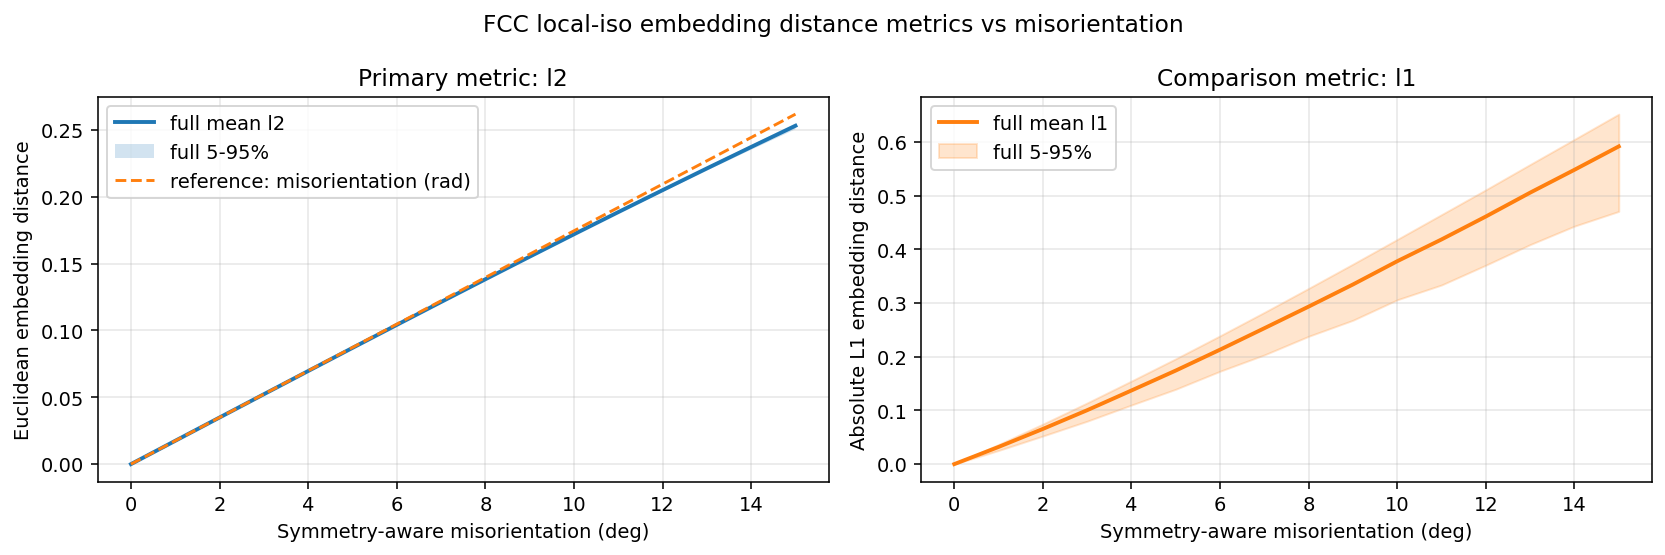

In [26]:
torch.manual_seed(0)

angles_deg = list(range(0, 16))
num_axes = 4000
q_ref = torch.tensor([[1.0, 0.0, 0.0, 0.0]], dtype=torch.float32)
feat_ref_full = encoder.forward_full(q_ref)
feat_ref_a1 = encoder.forward_a1(q_ref)

rows = []
for ang in angles_deg:
    axis = torch.randn(num_axes, 3)
    q = axis_angle_to_quat(
        axis,
        torch.full((num_axes,), math.radians(float(ang)), dtype=torch.float32),
    )
    q = _normalize_quaternions(q)
    mis_deg = _misorientation_angle_sym(q_ref.expand_as(q), q, sym_ops).rad2deg()
    feat_full = encoder.forward_full(q)
    feat_a1 = encoder.forward_a1(q)
    diff_full = feat_full - feat_ref_full.expand_as(feat_full)
    diff_a1 = feat_a1 - feat_ref_a1.expand_as(feat_a1)
    l2_full = diff_full.pow(2).sum(dim=-1).sqrt()
    l2_a1 = diff_a1.pow(2).sum(dim=-1).sqrt()
    l1_full = diff_full.abs().sum(dim=-1)
    l1_a1 = diff_a1.abs().sum(dim=-1)
    rows.append({
        "angle_deg": float(ang),
        "mis_mean_deg": float(mis_deg.mean().item()),
        "l2_full_mean": float(l2_full.mean().item()),
        "l2_full_q05": float(l2_full.quantile(0.05).item()),
        "l2_full_q95": float(l2_full.quantile(0.95).item()),
        "l2_a1_mean": float(l2_a1.mean().item()),
        "l1_full_mean": float(l1_full.mean().item()),
        "l1_full_q05": float(l1_full.quantile(0.05).item()),
        "l1_full_q95": float(l1_full.quantile(0.95).item()),
        "l1_a1_mean": float(l1_a1.mean().item()),
    })

for row in rows:
    print(
        f"angle={row['angle_deg']:>4.0f} deg | "
        f"mis={row['mis_mean_deg']:.3f} deg | "
        f"l2_full={row['l2_full_mean']:.6f} "
        f"[{row['l2_full_q05']:.6f}, {row['l2_full_q95']:.6f}] | "
        f"l1_full={row['l1_full_mean']:.6f} "
        f"[{row['l1_full_q05']:.6f}, {row['l1_full_q95']:.6f}]"
    )

x = [r['mis_mean_deg'] for r in rows]
l2_y = [r['l2_full_mean'] for r in rows]
l2_lo = [r['l2_full_q05'] for r in rows]
l2_hi = [r['l2_full_q95'] for r in rows]
l1_y = [r['l1_full_mean'] for r in rows]
l1_lo = [r['l1_full_q05'] for r in rows]
l1_hi = [r['l1_full_q95'] for r in rows]
l2_ref = [math.radians(v) for v in x]

fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=140)

axes[0].plot(x, l2_y, label='full mean l2', linewidth=2)
axes[0].fill_between(x, l2_lo, l2_hi, alpha=0.2, label='full 5-95%')
axes[0].plot(x, l2_ref, '--', label='reference: misorientation (rad)', linewidth=1.5)
axes[0].set_xlabel('Symmetry-aware misorientation (deg)')
axes[0].set_ylabel('Euclidean embedding distance')
axes[0].set_title('Primary metric: l2')
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(x, l1_y, label='full mean l1', linewidth=2, color='tab:orange')
axes[1].fill_between(x, l1_lo, l1_hi, alpha=0.2, color='tab:orange', label='full 5-95%')
axes[1].set_xlabel('Symmetry-aware misorientation (deg)')
axes[1].set_ylabel('Absolute L1 embedding distance')
axes[1].set_title('Comparison metric: l1')
axes[1].grid(alpha=0.3)
axes[1].legend()

fig.suptitle('FCC local-iso embedding distance metrics vs misorientation')
fig.tight_layout()
plt.show()


## 2. Threshold lookup

This cell turns both `l2` and `l1` cutoffs into approximate misorientation cutoffs, using the mean full-feature curves.

Because the embedding is close to isometric here, `l2` should line up directly with angle in radians. The `l1` lookup is included only as a practical comparison table.


In [27]:
torch.manual_seed(1)

angles_deg = torch.arange(0, 31, dtype=torch.float32)
num_axes = 4096
q_ref = torch.tensor([[1.0, 0.0, 0.0, 0.0]], dtype=torch.float32)
feat_ref = encoder.forward_full(q_ref)

l2_means = []
l1_means = []
for ang in angles_deg.tolist():
    axis = torch.randn(num_axes, 3)
    q = axis_angle_to_quat(
        axis,
        torch.full((num_axes,), math.radians(float(ang)), dtype=torch.float32),
    )
    q = _normalize_quaternions(q)
    feat = encoder.forward_full(q)
    diff = feat - feat_ref.expand_as(feat)
    l2 = diff.pow(2).sum(dim=-1).sqrt()
    l1 = diff.abs().sum(dim=-1)
    l2_means.append(float(l2.mean().item()))
    l1_means.append(float(l1.mean().item()))

print('Euclidean distance lookup:')
l2_thresholds = [0.020, 0.035, 0.050, 0.070, 0.090, 0.120, 0.150, 0.180, 0.200, 0.250]
for thr in l2_thresholds:
    keep_angles = [ang for ang, l2_val in zip(angles_deg.tolist(), l2_means) if l2_val <= thr]
    angle_keep = keep_angles[-1] if keep_angles else None
    approx_deg_from_rad = math.degrees(thr)
    if angle_keep is None:
        print(f"l2 <= {thr:.3f} (~ {approx_deg_from_rad:.1f} deg via rad) -> below sampled range")
    else:
        print(f"l2 <= {thr:.3f} (~ {approx_deg_from_rad:.1f} deg via rad) -> roughly <= {angle_keep:.0f} deg")

print()
print('Absolute L1 distance lookup:')
l1_thresholds = [0.04, 0.08, 0.12, 0.15, 0.18, 0.20, 0.25, 0.30]
for thr in l1_thresholds:
    keep_angles = [ang for ang, l1_val in zip(angles_deg.tolist(), l1_means) if l1_val <= thr]
    angle_keep = keep_angles[-1] if keep_angles else None
    if angle_keep is None:
        print(f"l1 <= {thr:.2f} -> below sampled range")
    else:
        print(f"l1 <= {thr:.2f} -> roughly <= {angle_keep:.0f} deg")


Euclidean distance lookup:
l2 <= 0.020 (~ 1.1 deg via rad) -> roughly <= 1 deg
l2 <= 0.035 (~ 2.0 deg via rad) -> roughly <= 2 deg
l2 <= 0.050 (~ 2.9 deg via rad) -> roughly <= 2 deg
l2 <= 0.070 (~ 4.0 deg via rad) -> roughly <= 4 deg
l2 <= 0.090 (~ 5.2 deg via rad) -> roughly <= 5 deg
l2 <= 0.120 (~ 6.9 deg via rad) -> roughly <= 6 deg
l2 <= 0.150 (~ 8.6 deg via rad) -> roughly <= 8 deg
l2 <= 0.180 (~ 10.3 deg via rad) -> roughly <= 10 deg
l2 <= 0.200 (~ 11.5 deg via rad) -> roughly <= 11 deg
l2 <= 0.250 (~ 14.3 deg via rad) -> roughly <= 14 deg

Absolute L1 distance lookup:
l1 <= 0.04 -> roughly <= 1 deg
l1 <= 0.08 -> roughly <= 2 deg
l1 <= 0.12 -> roughly <= 3 deg
l1 <= 0.15 -> roughly <= 4 deg
l1 <= 0.18 -> roughly <= 5 deg
l1 <= 0.20 -> roughly <= 5 deg
l1 <= 0.25 -> roughly <= 6 deg
l1 <= 0.30 -> roughly <= 8 deg


## 3. Random-pair sanity check

The fixed-reference sweep is the cleanest way to build a lookup.

This random-pair check is here to confirm that both `l2` and `l1` stay well ordered when pairwise samples are binned by symmetry-aware misorientation.


In [28]:
torch.manual_seed(2)

num_pairs = 20000
q1 = _normalize_quaternions(torch.randn(num_pairs, 4))
q2 = _normalize_quaternions(torch.randn(num_pairs, 4))
mis_deg = _misorientation_angle_sym(q1, q2, sym_ops).rad2deg()
feat1 = encoder.forward_full(q1)
feat2 = encoder.forward_full(q2)
diff = feat1 - feat2
l2 = diff.pow(2).sum(dim=-1).sqrt()
l1 = diff.abs().sum(dim=-1)

bins = [(0, 2), (2, 3), (3, 5), (5, 7), (7, 10), (10, 15), (15, 20)]
for lo, hi in bins:
    mask = (mis_deg >= lo) & (mis_deg < hi)
    if int(mask.sum()) == 0:
        continue
    vals_l2 = l2[mask]
    vals_l1 = l1[mask]
    print(
        f"bin [{lo:>2}, {hi:>2}) deg | count={int(mask.sum()):>5} | "
        f"l2 mean={vals_l2.mean().item():.6f} q05={vals_l2.quantile(0.05).item():.6f} q95={vals_l2.quantile(0.95).item():.6f} | "
        f"l1 mean={vals_l1.mean().item():.6f} q05={vals_l1.quantile(0.05).item():.6f} q95={vals_l1.quantile(0.95).item():.6f}"
    )


bin [ 2,  3) deg | count=    4 | l2 mean=0.043153 q05=0.037622 q95=0.047678 | l1 mean=0.105621 q05=0.091873 q95=0.117819
bin [ 3,  5) deg | count=    8 | l2 mean=0.077505 q05=0.067738 q95=0.083956 | l1 mean=0.197315 q05=0.167726 q95=0.222641
bin [ 5,  7) deg | count=   33 | l2 mean=0.105944 q05=0.089707 q95=0.120312 | l1 mean=0.262458 q05=0.219879 q95=0.311013
bin [ 7, 10) deg | count=  103 | l2 mean=0.151843 q05=0.127093 q95=0.169910 | l1 mean=0.372248 q05=0.294568 q95=0.438273
bin [10, 15) deg | count=  293 | l2 mean=0.217353 q05=0.177196 q95=0.250054 | l1 mean=0.535076 q05=0.409621 q95=0.643291
bin [15, 20) deg | count=  601 | l2 mean=0.295383 q05=0.259187 q95=0.326428 | l1 mean=0.725686 q05=0.602267 q95=0.848947


## 4. Interpretation for OCRP / HR-conv masking

If the goal is to avoid boundary leakage while still permitting strong same-orientation mixing, a simple rule is:

1. Compute the primary embedding distance to the center feature: `l2 = ||f_neighbor - f_center||_2`.
2. Optionally compute `l1 = ||f_neighbor - f_center||_1` as a comparison metric.
3. Keep only neighbors whose chosen distance is below a cutoff.
4. Renormalize the surviving weights.

A practical FCC starting point from this notebook:
- `l2 <= 0.07` for a strict mask, about `<= 4 deg`
- `l2 <= 0.09` for a moderate mask, about `<= 5 deg`
- `l2 <= 0.15` for a looser mask, about `<= 8 deg`
- `l1 <= 0.12` is a rough comparison point for about `<= 3 deg`
- `l1 <= 0.18` is a rough comparison point for about `<= 5 deg`
- `l1 <= 0.30` is a rough comparison point for about `<= 8 deg`

Because the local-iso embedding is meant to be isometric, the cleaner mental rule is built on `l2`:
- `l2 ≈ misorientation_rad`
- equivalently, for a target angle `theta_deg`, start with `cutoff ≈ theta_deg * pi / 180`

So if you need one physically interpretable masking metric, prefer `l2`. Keep `l1` only as a robustness or implementation comparison.

Important caveat:
- these cutoffs were measured on the FCC local-iso embedding and are most directly justified for the `forward_full` feature space used by OCRP.
- if you switch irreps or add more pre/post feature transforms, rerun this notebook and rebuild the lookup.


Controlled samples with misorientation < 3 deg: 6000
l2 | mean=0.025982 q05=0.002460 q95=0.049617
l1 | mean=0.048845 q05=0.004285 q95=0.098125
corr(l2, mis_rad) = 0.999996


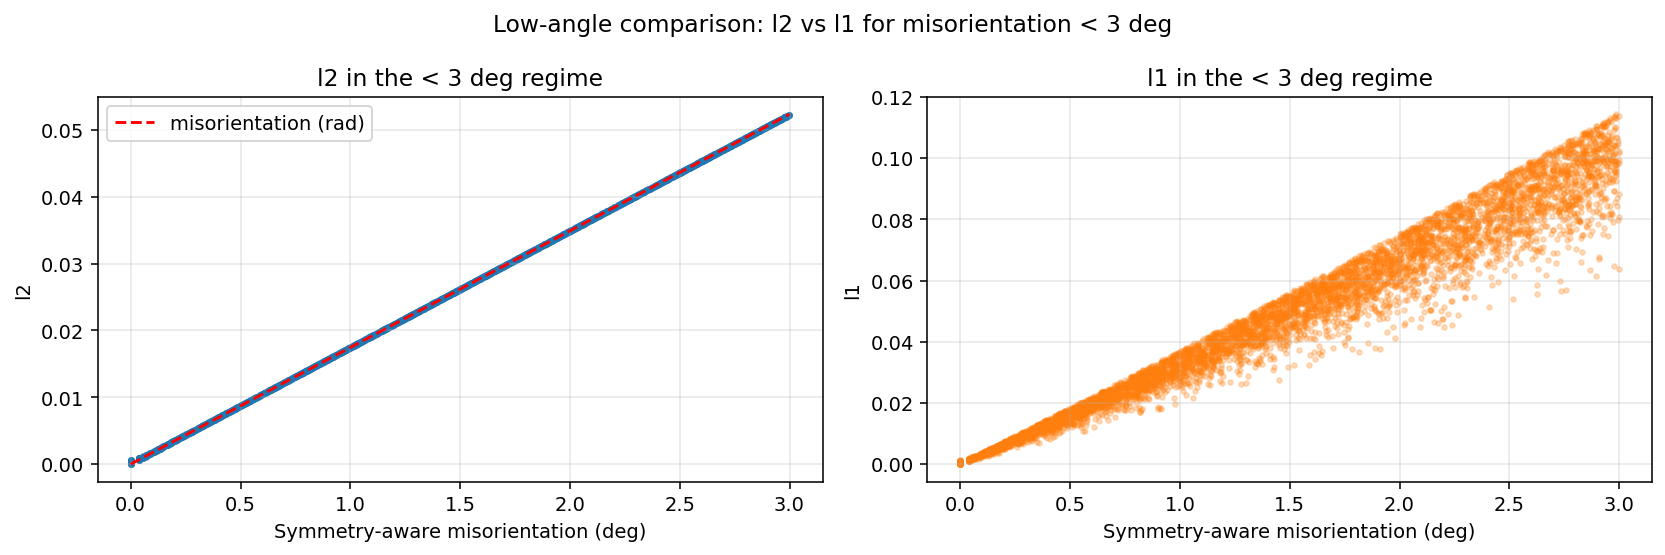

In [29]:
# Final comparison: controlled low-angle regime (< 3 deg)
torch.manual_seed(3)

num_samples = 6000
angles_deg = 3.0 * torch.rand(num_samples, dtype=torch.float32)
axes = torch.randn(num_samples, 3)
q = axis_angle_to_quat(axes, angles_deg * math.pi / 180.0)
q = _normalize_quaternions(q)
mis_deg = _misorientation_angle_sym(q_ref.expand_as(q), q, sym_ops).rad2deg()
feat = encoder.forward_full(q)
diff = feat - feat_ref_full.expand_as(feat)
l2 = diff.pow(2).sum(dim=-1).sqrt()
l1 = diff.abs().sum(dim=-1)
mis_rad = mis_deg * math.pi / 180.0

print(f'Controlled samples with misorientation < 3 deg: {int((mis_deg < 3.0).sum())}')
print(f'l2 | mean={l2.mean().item():.6f} q05={l2.quantile(0.05).item():.6f} q95={l2.quantile(0.95).item():.6f}')
print(f'l1 | mean={l1.mean().item():.6f} q05={l1.quantile(0.05).item():.6f} q95={l1.quantile(0.95).item():.6f}')
print(f'corr(l2, mis_rad) = {torch.corrcoef(torch.stack([l2, mis_rad]))[0, 1].item():.6f}')

fig, axes_plot = plt.subplots(1, 2, figsize=(12, 4), dpi=140)
axes_plot[0].scatter(mis_deg.cpu(), l2.cpu(), s=6, alpha=0.25)
axes_plot[0].plot([0, 3], [0, 3.0 * math.pi / 180.0], 'r--', linewidth=1.5, label='misorientation (rad)')
axes_plot[0].set_xlabel('Symmetry-aware misorientation (deg)')
axes_plot[0].set_ylabel('l2')
axes_plot[0].set_title('l2 in the < 3 deg regime')
axes_plot[0].grid(alpha=0.3)
axes_plot[0].legend()

axes_plot[1].scatter(mis_deg.cpu(), l1.cpu(), s=6, alpha=0.25, color='tab:orange')
axes_plot[1].set_xlabel('Symmetry-aware misorientation (deg)')
axes_plot[1].set_ylabel('l1')
axes_plot[1].set_title('l1 in the < 3 deg regime')
axes_plot[1].grid(alpha=0.3)

fig.suptitle('Low-angle comparison: l2 vs l1 for misorientation < 3 deg')
fig.tight_layout()
plt.show()
